# Notebook 05: Discrimination (SQ1)

Replaces the pooled-row bootstrap with run-level bootstrap (primary unit of analysis = one run) and reframes the primary outcome as the difference of transfer gaps, computed and reported per architecture, per the supervisor's review. Cluster (image-level) bootstrap is retained as a secondary sensitivity check on the pooled K2N-vs-N2K contrast.

## 1. Setup and Load Saved Predictions

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except ImportError:
    pass

import sys
from pathlib import Path

REPO_ON_DRIVE = "/content/drive/MyDrive/MSc AI DISSERTATION/crosspop-cxr-asymmetry"
for candidate in [REPO_ON_DRIVE, "..", "."]:
    p = Path(candidate).resolve()
    if (p / "config.py").exists():
        sys.path.insert(0, str(p))
        break

import importlib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import config
from src import metrics as MET
from src import stats as ST
from src import results as RES

for mod in (config, MET, ST, RES):
    importlib.reload(mod)

config.ensure_output_dirs()
config.set_plot_style()


Mounted at /content/drive


In [2]:
ext_summary = pd.read_csv(config.RESULTS_DIR / "04_inference_summary_extended.csv")
print(f"Loaded extended inference summary: {ext_summary.shape}")
print(ext_summary.groupby(["condition", "arch"]).size().to_string())


Loaded extended inference summary: (114, 16)
condition  arch           
K2K        efficientnet_b0     9
           mobilenet_v2        9
K2N        efficientnet_b0     9
           mobilenet_v2        9
K2N_full   efficientnet_b0     9
           mobilenet_v2        9
N2K        efficientnet_b0    15
           mobilenet_v2       15
N2N        efficientnet_b0    15
           mobilenet_v2       15


In [3]:
ext_summary = pd.read_csv(config.RESULTS_DIR / "04_inference_summary_extended.csv")
meta, arrays = RES.load_predictions(config.RESULTS_DIR / "predictions")
print(f"Loaded extended inference summary: {ext_summary.shape}")
print(ext_summary.groupby(["condition", "arch"]).size().to_string())

Loaded extended inference summary: (114, 16)
condition  arch           
K2K        efficientnet_b0     9
           mobilenet_v2        9
K2N        efficientnet_b0     9
           mobilenet_v2        9
K2N_full   efficientnet_b0     9
           mobilenet_v2        9
N2K        efficientnet_b0    15
           mobilenet_v2       15
N2N        efficientnet_b0    15
           mobilenet_v2       15


## 2. Per-architecture, per-condition AUROC summary

In [4]:
print("\n--- Per-architecture, per-condition AUROC (mean +/- SD across runs) ---")
agg = ext_summary.groupby(["condition", "arch"])["auroc"].agg(["mean", "std", "count"]).round(3)
print(agg.to_string())



--- Per-architecture, per-condition AUROC (mean +/- SD across runs) ---
                            mean    std  count
condition arch                                
K2K       efficientnet_b0  0.964  0.015      9
          mobilenet_v2     0.961  0.020      9
K2N       efficientnet_b0  0.610  0.119      9
          mobilenet_v2     0.644  0.099      9
K2N_full  efficientnet_b0  0.632  0.038      9
          mobilenet_v2     0.629  0.025      9
N2K       efficientnet_b0  0.730  0.108     15
          mobilenet_v2     0.590  0.179     15
N2N       efficientnet_b0  0.702  0.111     15
          mobilenet_v2     0.725  0.095     15


## 3. Primary uncertainty: run-level bootstrap per condition x architecture

Unit of analysis = one run (one seed for K2N/K2K/K2N_full/N2N; one seed-fold for N2K). This resamples runs, not raw prediction rows, so run-to-run noise is correctly propagated instead of an inflated pseudo-n from pooled rows.

In [5]:
rows = []
for (cond, arch), grp in ext_summary.groupby(["condition", "arch"]):
    vals = grp["auroc"].values
    mean_est, lo, hi, _ = ST.run_level_bootstrap_ci(
        vals, n_boot=config.BOOTSTRAP_N, ci=config.BOOTSTRAP_CI, seed=config.SEED
    )
    rows.append({
        "condition": cond, "arch": arch, "n_runs": len(vals),
        "auroc_mean": round(mean_est, 3), "auroc_lo": round(lo, 3), "auroc_hi": round(hi, 3)
    })

run_level_table = pd.DataFrame(rows).sort_values(["arch", "condition"])
print("\n--- Run-level bootstrap AUROC CIs (PRIMARY) ---")
print(run_level_table.to_string(index=False))
run_level_table.to_csv(config.RESULTS_DIR / "05_run_level_auroc.csv", index=False)



--- Run-level bootstrap AUROC CIs (PRIMARY) ---
condition            arch  n_runs  auroc_mean  auroc_lo  auroc_hi
      K2K efficientnet_b0       9       0.964     0.954     0.973
      K2N efficientnet_b0       9       0.610     0.541     0.689
 K2N_full efficientnet_b0       9       0.632     0.609     0.656
      N2K efficientnet_b0      15       0.730     0.676     0.782
      N2N efficientnet_b0      15       0.702     0.645     0.754
      K2K    mobilenet_v2       9       0.961     0.948     0.973
      K2N    mobilenet_v2       9       0.644     0.587     0.709
 K2N_full    mobilenet_v2       9       0.629     0.612     0.644
      N2K    mobilenet_v2      15       0.590     0.495     0.676
      N2N    mobilenet_v2      15       0.725     0.678     0.769


## 4. Secondary check: cluster (image-level) bootstrap on pooled K2N vs N2K

Independent verification using a different resampling unit (unique images, not runs). If this materially disagrees with the run-level result above, that disagreement itself is worth reporting.

In [6]:
y_true_k2n, y_prob_k2n, img_k2n = RES.pool_predictions(
    meta, arrays, condition="K2N", include_image_id=True
)
y_true_n2k, y_prob_n2k, img_n2k = RES.pool_predictions(
    meta, arrays, condition="N2K", include_image_id=True
)

_, k2n_lo_c, k2n_hi_c, _ = ST.cluster_bootstrap_ci(
    y_true_k2n, y_prob_k2n, img_k2n, MET.auroc, n_boot=config.BOOTSTRAP_N, seed=config.SEED
)
_, n2k_lo_c, n2k_hi_c, _ = ST.cluster_bootstrap_ci(
    y_true_n2k, y_prob_n2k, img_n2k, MET.auroc, n_boot=config.BOOTSTRAP_N, seed=config.SEED
)

print("\n--- Secondary check: cluster (image-level) bootstrap AUROC ---")
print(f"K2N: {MET.auroc(y_true_k2n, y_prob_k2n):.3f}  [{k2n_lo_c:.3f}, {k2n_hi_c:.3f}]  (n_images={len(np.unique(img_k2n))})")
print(f"N2K: {MET.auroc(y_true_n2k, y_prob_n2k):.3f}  [{n2k_lo_c:.3f}, {n2k_hi_c:.3f}]  (n_images={len(np.unique(img_n2k))})")
print("Compare these image-clustered widths against the run-level widths above and "
      "against the (now-retired) naive pooled-row widths reported in earlier drafts; "
      "the naive version was materially too narrow due to pseudoreplication.")



--- Secondary check: cluster (image-level) bootstrap AUROC ---
K2N: 0.624  [0.524, 0.728]  (n_images=78)
N2K: 0.662  [0.642, 0.682]  (n_images=624)
Compare these image-clustered widths against the run-level widths above and against the (now-retired) naive pooled-row widths reported in earlier drafts; the naive version was materially too narrow due to pseudoreplication.


## 5. Transfer gaps (double difference), per architecture

Gap_K = AUROC(K2K) - AUROC(K2N)   (drop when a Kermany-trained model sees Togunwa)

Gap_N = AUROC(N2N) - AUROC(N2K)   (drop when a Togunwa-trained model sees Kermany)

Asymmetry = Gap_K - Gap_N

K2K and K2N share seeds (paired). N2N and N2K share seeds (paired; N2K fold-level AUROC is averaged to one value per seed for pairing with N2N).

K2N here uses the 30-image holdout condition (not K2N_full), because N2N is only defined on the 30-image holdout -- this keeps Gap_K and Gap_N evaluated on matched-size targets (30 vs 624) so the double difference at least controls for target-set difficulty, even though absolute sample sizes still differ.

In [7]:
def paired_seed_values(df, condition, arch):
    """Returns (seed -> auroc) dict for a given condition/arch, using fold-mean
    for N2K (5 folds per seed) or the single value for K2N (1 per seed)."""
    sub = df[(df.condition == condition) & (df.arch == arch)]
    return sub.groupby("seed")["auroc"].mean().sort_index()

print("\n--- Transfer gaps per architecture ---")
gap_rows = []
for arch in config.ARCHITECTURES:
    kk = paired_seed_values(ext_summary, "K2K", arch)
    kn = paired_seed_values(ext_summary, "K2N", arch)
    nn = paired_seed_values(ext_summary, "N2N", arch)
    nk = paired_seed_values(ext_summary, "N2K", arch)

    common_k_seeds = sorted(set(kk.index) & set(kn.index))
    common_n_seeds = sorted(set(nn.index) & set(nk.index))

    gap_k_vals = (kk.loc[common_k_seeds] - kn.loc[common_k_seeds]).values
    gap_n_vals = (nn.loc[common_n_seeds] - nk.loc[common_n_seeds]).values

    gap_k_mean, gap_k_lo, gap_k_hi, gap_k_boot = ST.run_level_bootstrap_ci(gap_k_vals, seed=config.SEED)
    gap_n_mean, gap_n_lo, gap_n_hi, gap_n_boot = ST.run_level_bootstrap_ci(gap_n_vals, seed=config.SEED)

    # Asymmetry: independent bootstrap resample of each gap, then difference
    # (gap_k and gap_n use disjoint seed pairings across different directions,
    # so treated as independent here)
    n_common = min(len(gap_k_boot), len(gap_n_boot))
    if n_common > 0:
        asym_boot = gap_k_boot[:n_common] - gap_n_boot[:n_common]
        asym_mean = float(asym_boot.mean())
        asym_lo, asym_hi = np.percentile(asym_boot, [2.5, 97.5])
    else:
        asym_boot = np.array([])
        asym_mean, asym_lo, asym_hi = gap_k_mean - gap_n_mean, float("nan"), float("nan")

    gap_rows.append({
        "arch": arch,
        "n_seeds_K": len(common_k_seeds), "n_seeds_N": len(common_n_seeds),
        "gap_K": round(gap_k_mean, 3), "gap_K_lo": round(gap_k_lo, 3), "gap_K_hi": round(gap_k_hi, 3),
        "gap_N": round(gap_n_mean, 3), "gap_N_lo": round(gap_n_lo, 3), "gap_N_hi": round(gap_n_hi, 3),
        "asymmetry": round(asym_mean, 3), "asym_lo": round(asym_lo, 3), "asym_hi": round(asym_hi, 3),
    })

gap_table = pd.DataFrame(gap_rows)
print(gap_table.to_string(index=False))
gap_table.to_csv(config.RESULTS_DIR / "05_transfer_gaps.csv", index=False)



--- Transfer gaps per architecture ---
           arch  n_seeds_K  n_seeds_N  gap_K  gap_K_lo  gap_K_hi  gap_N  gap_N_lo  gap_N_hi  asymmetry  asym_lo  asym_hi
   mobilenet_v2          3          3  0.316     0.196     0.384  0.135     0.034     0.214      0.182    0.039    0.336
efficientnet_b0          3          3  0.353     0.196     0.458 -0.028    -0.068     0.031      0.382    0.165    0.525


## 6. Figure: transfer gaps by direction and architecture

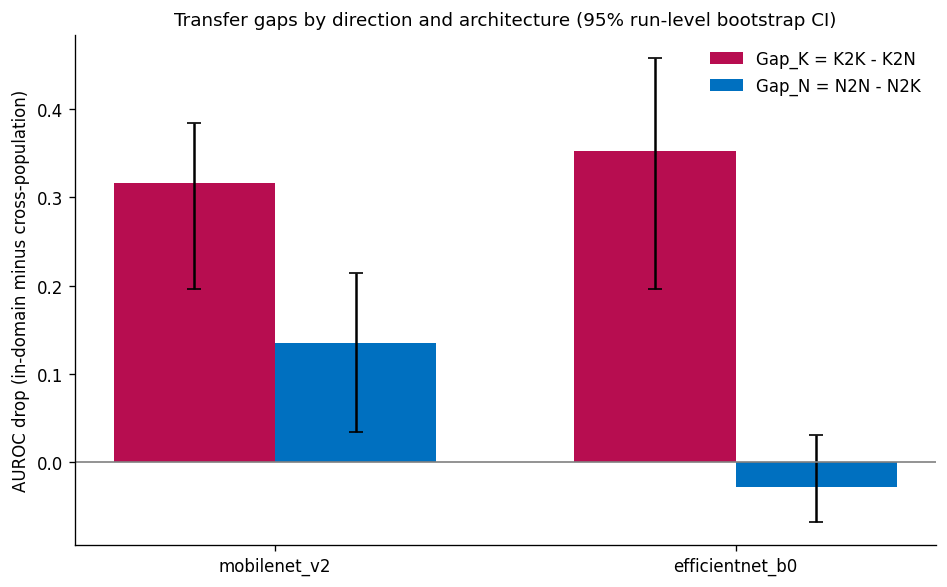

In [8]:
fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(gap_table))
width = 0.35

gap_k_means = gap_table["gap_K"].values
gap_n_means = gap_table["gap_N"].values
gap_k_err = [gap_table["gap_K"] - gap_table["gap_K_lo"], gap_table["gap_K_hi"] - gap_table["gap_K"]]
gap_n_err = [gap_table["gap_N"] - gap_table["gap_N_lo"], gap_table["gap_N_hi"] - gap_table["gap_N"]]

ax.bar(x - width/2, gap_k_means, width, yerr=gap_k_err, capsize=4,
       label="Gap_K = K2K - K2N", color=config.BRAND["C1"])
ax.bar(x + width/2, gap_n_means, width, yerr=gap_n_err, capsize=4,
       label="Gap_N = N2N - N2K", color=config.BRAND["C3"])
ax.axhline(0, color="grey", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(gap_table["arch"])
ax.set_ylabel("AUROC drop (in-domain minus cross-population)")
ax.set_title("Transfer gaps by direction and architecture (95% run-level bootstrap CI)")
ax.legend()
fig.tight_layout()
fig.savefig(config.FIGURES_DIR / "05_transfer_gaps.png", dpi=120, bbox_inches="tight")
plt.show()


**Next:** notebook 06 (calibration, SQ2).